# CIFAR-10 Convolutional Autoencoder and Latent-Space Selection

This notebook studies how latent dimensionality affects a convolutional autoencoder on CIFAR-10.

The model combines:

- a convolutional encoder,
- a compact dense latent vector,
- L1 activity regularization,
- an explicit latent L2 penalty,
- a transposed-convolution decoder,
- early stopping,
- reconstruction MSE,
- and a compactness-aware ranking criterion.

The experiments compare latent dimensions of 8, 16, 32, and 64.


## Imports and CIFAR-10 Data


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers as L
from tensorflow.keras import Model
from tensorflow.keras.regularizers import l1
from sklearn.metrics import mean_squared_error

(x_full, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_full = x_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Keep the official CIFAR-10 test split exclusively for final evaluation.
rng = np.random.default_rng(42)
indices = rng.permutation(len(x_full))

val_size = 5000
val_idx = indices[:val_size]
train_idx = indices[val_size:]

x_val = x_full[val_idx]
x_train = x_full[train_idx]

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1605s 9us/step
Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


## Latent Penalty Layer

The custom layer adds an L2-style penalty on the latent vector to the model loss. This encourages compact latent representations.


In [15]:
class LatentPenalty(L.Layer):
    def __init__(
        self,
        beta_latent=1e-3,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.beta_latent = beta_latent

    def call(self, z):
        latent_penalty = self.beta_latent * tf.reduce_mean(
            tf.reduce_sum(
                tf.square(z),
                axis=1,
            )
        )
        self.add_loss(latent_penalty)
        return z


## Build the Convolutional Autoencoder

The encoder reduces a 32×32 RGB image to a configurable latent vector. The decoder reconstructs the image using transposed convolutions.


In [16]:
def build_cae(
    input_shape=(32, 32, 3),
    latent_dim=32,
    beta_latent=1e-3,
    l1_activity=0.0,
):
    inputs = L.Input(
        shape=input_shape,
    )

    x = L.Conv2D(
        64,
        3,
        padding="same",
        activation="relu",
    )(inputs)
    x = L.MaxPooling2D()(x)

    x = L.Conv2D(
        128,
        3,
        padding="same",
        activation="relu",
    )(x)
    x = L.MaxPooling2D()(x)

    x = L.Conv2D(
        256,
        3,
        padding="same",
        activation="relu",
    )(x)
    x = L.MaxPooling2D()(x)

    x = L.Conv2D(
        256,
        3,
        padding="same",
        activation="relu",
    )(x)
    x = L.BatchNormalization()(x)
    x = L.Flatten()(x)
    x = L.Dense(
        512,
        activation="relu",
    )(x)

    z = L.Dense(
        latent_dim,
        name="latent",
        activation=None,
        activity_regularizer=(
            l1(l1_activity)
            if l1_activity > 0
            else None
        ),
    )(x)

    z = LatentPenalty(
        beta_latent,
        name="latent_penalty",
    )(z)

    d = L.Dense(
        4 * 4 * 256,
        activation="relu",
    )(z)
    d = L.Reshape(
        (4, 4, 256)
    )(d)

    d = L.Conv2DTranspose(
        256,
        3,
        strides=2,
        padding="same",
        activation="relu",
    )(d)
    d = L.Conv2DTranspose(
        128,
        3,
        strides=2,
        padding="same",
        activation="relu",
    )(d)
    d = L.Conv2DTranspose(
        64,
        3,
        strides=2,
        padding="same",
        activation="relu",
    )(d)

    outputs = L.Conv2D(
        3,
        3,
        padding="same",
        activation="sigmoid",
    )(d)

    cae = Model(
        inputs,
        outputs,
        name=f"cae_latent{latent_dim}",
    )

    cae.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3,
        ),
        loss="mse",
    )

    return cae


## Training and Evaluation Function


In [17]:
def train_and_eval(
    latent_dim,
    beta_latent=1e-3,
    l1_activity=0.0,
    epochs=20,
    batch_size=256,
    verbose=1,
):
    tf.keras.backend.clear_session()

    cae = build_cae(
        input_shape=(32, 32, 3),
        latent_dim=latent_dim,
        beta_latent=beta_latent,
        l1_activity=l1_activity,
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ]

    history = cae.fit(
        x_train,
        x_train,
        validation_data=(x_val, x_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks,
    )

    xhat_test = cae.predict(
        x_test,
        verbose=0,
    )

    mse = mean_squared_error(
        x_test.reshape(
            len(x_test),
            -1,
        ),
        xhat_test.reshape(
            len(xhat_test),
            -1,
        ),
    )

    return cae, history, mse


## Latent-Dimension Sweep

Each latent dimension is trained independently. The final test set is used only after training and early-stopping decisions have been made using the validation split.


In [18]:
latent_dims = [
    8,
    16,
    32,
    64,
]

# Reduced latent regularization so larger latent spaces
# can use their additional representational capacity.
beta_latent = 1e-5
l1_activity = 0.0

epochs = 25
batch_size = 256

results = []
models = {}
histories = {}

for ld in latent_dims:
    print(
        f"\nTraining CAE with "
        f"latent_dim={ld}"
    )

    model, history, mse = train_and_eval(
        latent_dim=ld,
        beta_latent=beta_latent,
        l1_activity=l1_activity,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )

    models[ld] = model
    histories[ld] = history

    results.append(
        (ld, mse)
    )

print(
    "\nMSE vs. Latent Dimensionality"
)

for ld, mse in results:
    print(
        f"latent_dim={ld:>2d}  |  "
        f"test MSE={mse:.6f}"
    )


Training CAE with latent_dim=8
Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 0.0370 - val_loss: 0.0654
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0250 - val_loss: 0.0468
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0237 - val_loss: 0.0313
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0228 - val_loss: 0.0239
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0227 - val_loss: 0.0232
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0225 - val_loss: 0.0227
Epoch 7/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0223 - val_loss: 0.0225
Epoch 8/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0222 - val_loss: 0.0224
Epoch 9/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0221 - val_loss: 0.0244
Epoch 10/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0219 - val_loss: 0.0224
Epoch 11/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0219 - val_loss: 0.0222
Epoch 12

## Compactness-Aware Ranking

Reconstruction MSE alone favors models that can use larger latent spaces. The original experiment therefore also evaluates:

$$
J = \mathrm{MSE} + \lambda \left(\frac{\text{latent dimension}}{64}\right)
$$

where `lambda_dim` controls the penalty assigned to larger latent representations.


In [19]:
lambda_dim = 1e-3

ranked = sorted(
    results,
    key=lambda t: (
        t[1]
        + lambda_dim
        * (t[0] / 64.0)
    ),
)

print(
    "\nRanked by "
    "J = MSE + λ*(latent_dim/64) "
    f"(λ = {lambda_dim:.1e})"
)

for ld, mse in ranked:
    J = (
        mse
        + lambda_dim
        * (ld / 64.0)
    )

    print(
        f"latent_dim={ld:>2d} | "
        f"MSE={mse:.6f} | "
        f"J={J:.6f}"
    )

best_ld = ranked[0][0]

print(
    "\nSelected latent dimension:",
    best_ld,
)



Ranked by J = MSE + λ*(latent_dim/64) (λ = 1.0e-03)
latent_dim=64 | MSE=0.008277 | J=0.009277
latent_dim=32 | MSE=0.012126 | J=0.012626
latent_dim=16 | MSE=0.016571 | J=0.016821
latent_dim= 8 | MSE=0.021807 | J=0.021932

Selected latent dimension: 64


## Reconstruction Quality of the Selected Model


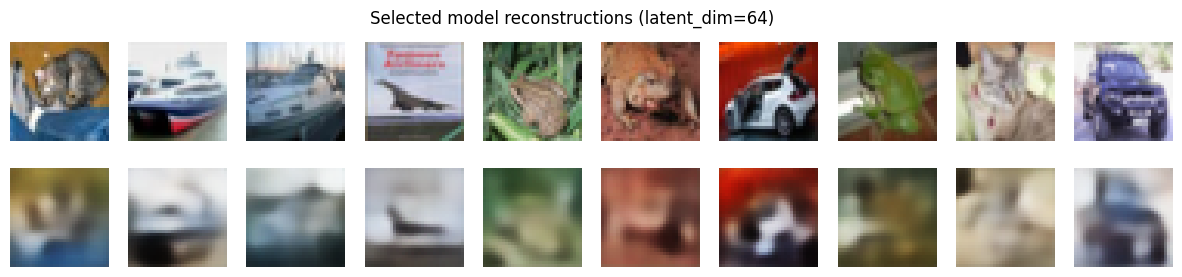

In [20]:
best_model = models[best_ld]

xhat = best_model.predict(
    x_test[:10],
    verbose=0,
)

fig, ax = plt.subplots(
    2,
    10,
    figsize=(15, 3),
)

for i in range(10):
    ax[0, i].imshow(
        x_test[i]
    )
    ax[0, i].axis("off")

    ax[1, i].imshow(
        xhat[i]
    )
    ax[1, i].axis("off")

plt.suptitle(
    f"Selected model reconstructions "
    f"(latent_dim={best_ld})"
)
plt.show()


## Reconstruction Quality Across Latent Dimensions

The latent-dimension comparison illustrates the tradeoff between compression and reconstruction quality. Smaller latent spaces provide stronger compression but lose more visual detail, while larger latent spaces retain more information and produce lower reconstruction error. With the current compactness penalty, the improvement in reconstruction quality is large enough that the 64-dimensional latent representation achieves the best overall ranking.

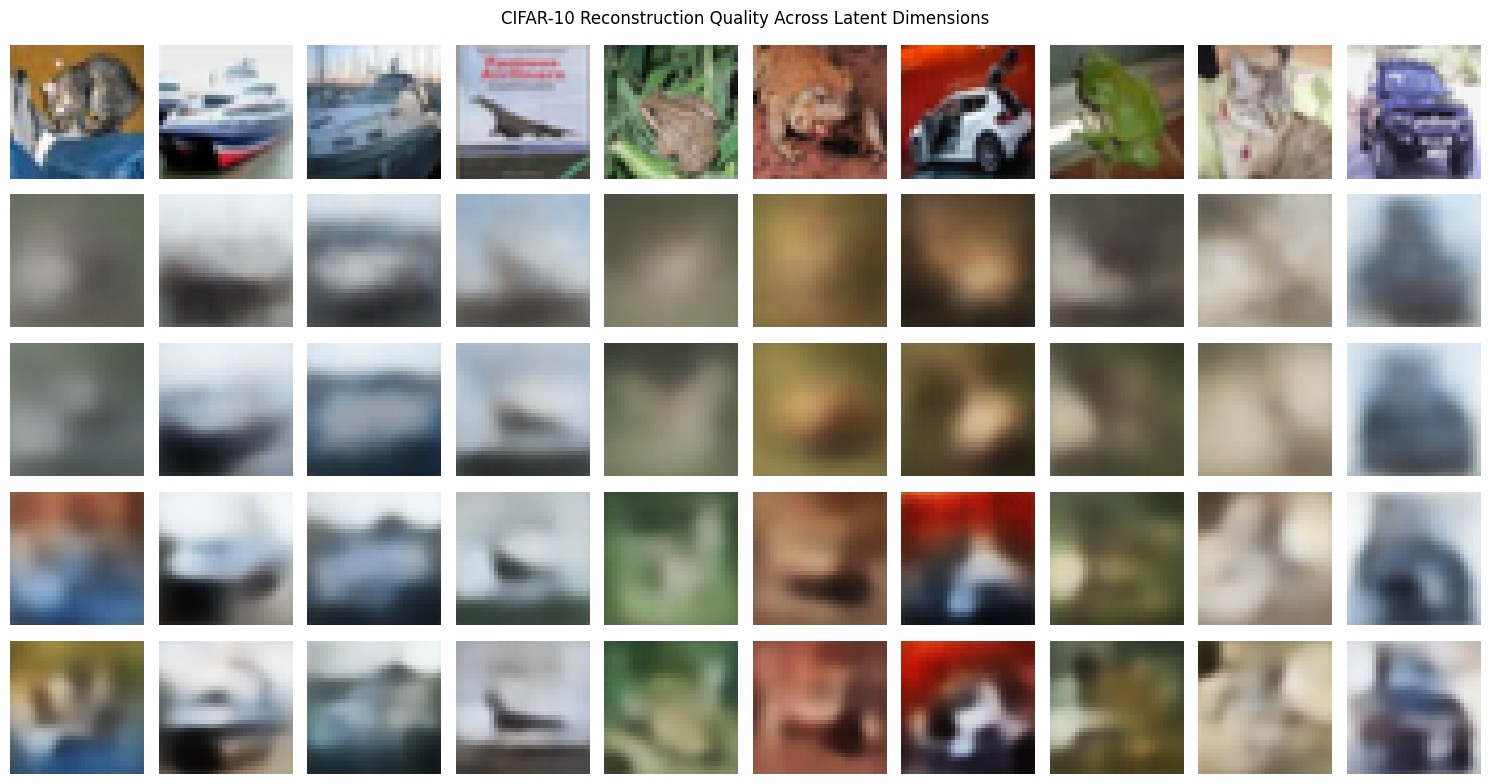

In [21]:
fig, ax = plt.subplots(
    len(latent_dims) + 1,
    10,
    figsize=(15, 8),
)

# Original test images
for i in range(10):
    ax[0, i].imshow(x_test[i])
    ax[0, i].axis("off")

ax[0, 0].set_ylabel(
    "Original",
    rotation=0,
    labelpad=40,
)

# Reconstructions for each latent dimension
for row, ld in enumerate(latent_dims, start=1):

    reconstructed = models[ld].predict(
        x_test[:10],
        verbose=0,
    )

    for i in range(10):
        ax[row, i].imshow(
            np.clip(reconstructed[i], 0, 1)
        )
        ax[row, i].axis("off")

    ax[row, 0].set_ylabel(
        f"Latent {ld}",
        rotation=0,
        labelpad=40,
    )

plt.suptitle(
    "CIFAR-10 Reconstruction Quality Across Latent Dimensions"
)

plt.tight_layout()
plt.show()

## Plot Test MSE vs. Latent Dimension


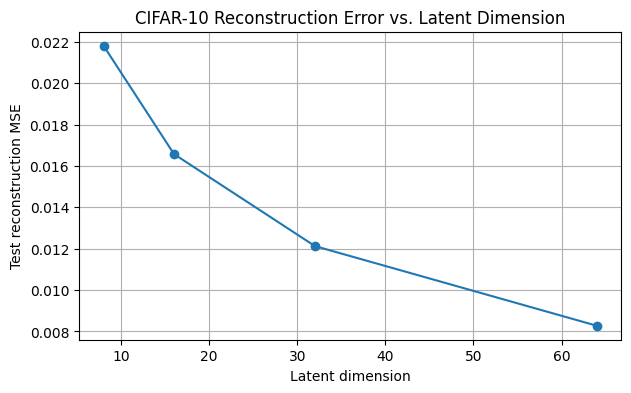

In [22]:
latent_values = [
    ld
    for ld, _ in results
]

mse_values = [
    mse
    for _, mse in results
]

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    latent_values,
    mse_values,
    marker="o",
)

plt.xlabel(
    "Latent dimension"
)
plt.ylabel(
    "Test reconstruction MSE"
)
plt.title(
    "CIFAR-10 Reconstruction Error "
    "vs. Latent Dimension"
)
plt.grid(True)
plt.show()


## Key Takeaways

Latent dimensionality creates a compression-reconstruction tradeoff. Smaller latent spaces provide stronger compression, while larger latent spaces generally have more capacity to preserve image detail.

The compactness-aware ranking makes that tradeoff explicit instead of selecting a model solely from reconstruction error. The validation split is kept separate from the official CIFAR-10 test set so model-selection decisions do not depend on final test performance.
